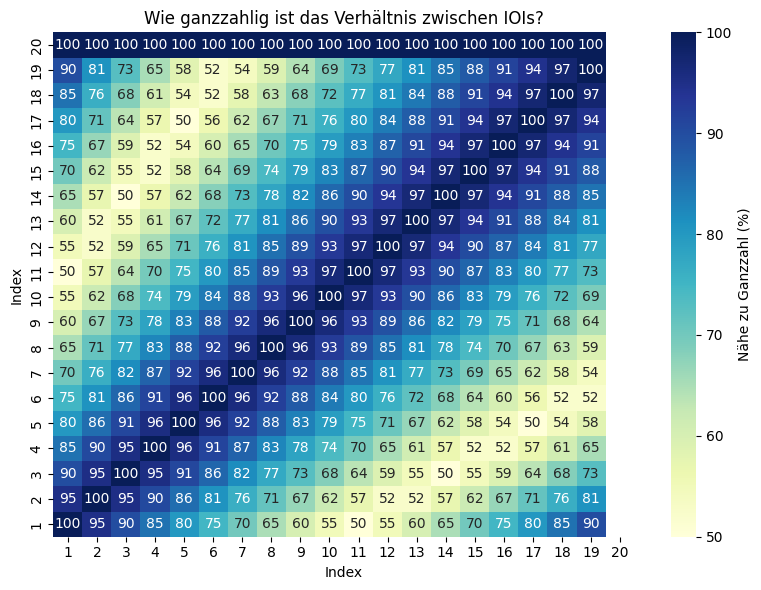

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Daten laden
df1 = pd.read_csv("/Users/emilschmiedl/Desktop/experimenting_with_RANTO/data/iois_zusammenfassung.csv")
df3 = pd.read_csv("/Users/emilschmiedl/Desktop/experimenting_with_RANTO/data/raw_deviations_zusammenfassung.csv")

# Filterbedingungen
filename = "isochron_drift.csv"
condition = "20_median"

df1_match = df1[(df1["full_filename"] == filename) & (df1["condition"] == condition)]

# Synchronisieren (nur df1 genutzt)
x_vals = df1_match["ioi"].values
y_vals = df1_match["ioi"].values

# Verhältnis-Matrix mit größer/kleiner
ratios = np.array([[max(x, y) / min(x, y) for x in x_vals] for y in y_vals])

import numpy as np

def proximity_max_freq(
    x,
    sharpness_base=10.0,         # Basis-Schärfe (gilt für freq = 1)
    sharpness_growth=2.0,        # Schärfenwachstum mit x
    decay=0.1,                   # Exponentieller Abfall mit wachsendem x
    max_freq=4,                  # Höchste zu berücksichtigende Frequenz
    weight_exponent=1.0,         # Wie stark die Amplitude mit Frequenz abnimmt (1/f^exp)
    freq_sharpness_exp=1.0,      # Wie stark die Sharpness mit Frequenz wächst
    norm_x=1.0,                  # Referenzpunkt für Normierung (x, bei dem Peaks auf max gesetzt werden)
    output_max=1.0               # Maximaler Rückgabewert (Skalierung der Ausgabe)
):
    x = np.array(x)

    all_freq_values = []

    for freq in range(1, max_freq + 1):
        # --- Gewichtung der Amplitude: je höher freq, desto kleiner (1/f^weight_exponent)
        weight = 1 / (freq ** weight_exponent)

        # --- Frequenzabhängige Sharpness:
        # Sowohl die Basis-Schärfe als auch das Wachstum der Schärfe mit x steigen mit freq
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        # --- Gesamtschärfe für diese Frequenz und x
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)

        # --- Cosinus-basiertes Proximity-Signal (zwischen 0 und 1, scharf am Peak)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        # --- Normierung dieses Frequenzsignals bei norm_x, sodass Peak = 1
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value

        # --- Gewichtung & Abfall mit x
        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)

    # --- Statt Summe oder Mittelwert wird das Maximum aller Frequenz-Werte pro x genommen
    result = np.maximum.reduce(all_freq_values)

    # --- Skalierung der maximal möglichen Ausgabe auf output_max
    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max


# Achsenbeschriftung als Indizes
xticks = list(range(1, len(x_vals) + 1))
yticks = list(range(1, len(y_vals) + 1))

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(proximity_max_freq(ratios), annot=True, fmt=".0f", cmap="YlGnBu",
            xticklabels=xticks, yticklabels=yticks, cbar_kws={"label": "Nähe zu Ganzzahl (%)"})

plt.gca().invert_yaxis()  # ✅ y-Achse richtig herum

plt.xlabel("Index")
plt.ylabel("Index")
plt.title("Wie ganzzahlig ist das Verhältnis zwischen IOIs?")
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Neue Proximity-Funktion basierend auf vorherigem Design
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []

    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)

        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value

        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)

    result = np.maximum.reduce(all_freq_values)

    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# --- Daten laden
df1 = pd.read_csv("/Users/emilschmiedl/Desktop/experimenting_with_RANTO/data/iois_zusammenfassung.csv")

filename = "isochron_drift.csv"
condition = "20_median"

df1_match = df1[(df1["full_filename"] == filename) & (df1["condition"] == condition)]
x_vals = df1_match["ioi"].values
y_vals = df1_match["ioi"].values

# Verhältnis-Matrix
ratios = np.array([[max(x, y) / min(x, y) for x in x_vals] for y in y_vals])

# Neue Proximity-Bewertung
proximity = proximity_max_freq(
    ratios,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)

# --- Plot-Panel
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Proximity-Funktion mit Punkten
x_range = np.linspace(1, 5, 1000)
y_curve = proximity_max_freq(x_range)
axes[0].plot(x_range, y_curve, label="Proximity-Funktion")
axes[0].scatter(ratios.flatten(), proximity.flatten(), color="red", s=10, alpha=0.7, label="IOI-Verhältnisse")
axes[0].set_title("Proximity-Funktion mit IOI-Verhältnissen")
axes[0].set_xlabel("Verhältnis")
axes[0].set_ylabel("Proximity")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Heatmap
sns.heatmap(proximity * 100, annot=True, fmt=".0f", cmap="YlGnBu",
            xticklabels=list(range(1, len(x_vals)+1)),
            yticklabels=list(range(1, len(y_vals)+1)),
            cbar_kws={"label": "Proximity (%)"}, ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title("Proximity-Matrix der IOI-Verhältnisse")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Index")

# Plot 3: Histogramm
axes[2].hist(proximity.flatten(), bins=20, color="skyblue", edgecolor="black")
axes[2].set_title("Histogramm der Proximity-Werte")
axes[2].set_xlabel("Proximity")
axes[2].set_ylabel("Anzahl")

plt.tight_layout()
plt.show()


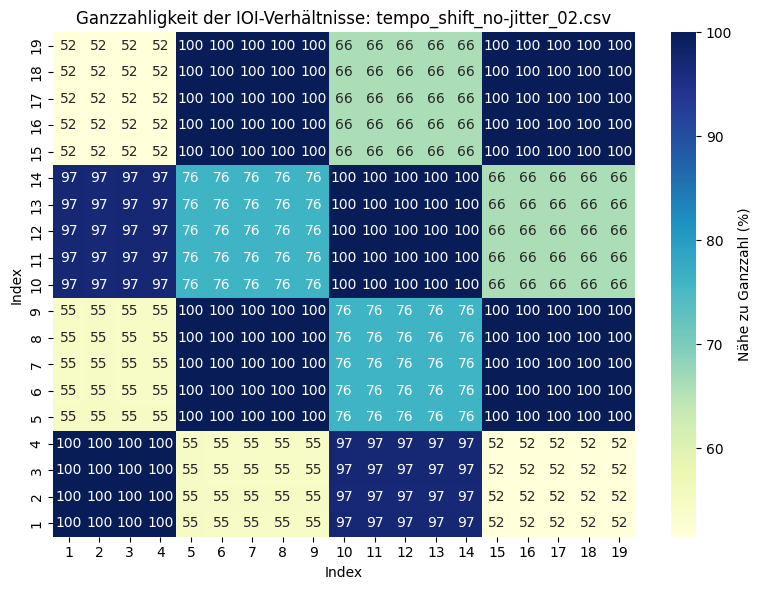

In [5]:
# für neu erstellte Sequeznzen
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Parameter setzen ===
num_beats = 20  # z.B. 6, 20 oder 100
filename = "tempo_shift_no-jitter_02.csv"  # Name aus deinem Synthese-Ordner

# === Pfad zur Sequenz ===
base_dir = "../data/theoretical_sequences"
seq_path = os.path.join(base_dir, f"synthetic_sequences_{num_beats}beats", filename)

# === Sequenz laden ===
df = pd.read_csv(seq_path)

# === IOIs extrahieren ===
iois = df["IOI"].dropna().values  # NaN am Ende entfernen

# === Verhältnis-Matrix berechnen ===
ratios = np.array([[max(x, y) / min(x, y) for x in iois] for y in iois])

# === Nähe zur Ganzzahl berechnen ===
rounded_ratios = np.round(ratios)
deviation = np.abs(ratios - rounded_ratios)
proximity = 1 - deviation  # 1 = perfekt ganzzahlig

# === Auf 0–100 skalieren ===
proximity_percent = np.clip(proximity * 100, 0, 100)

# === Plot ===
xticks = list(range(1, len(iois) + 1))
yticks = list(range(1, len(iois) + 1))

plt.figure(figsize=(8, 6))
sns.heatmap(proximity_percent, annot=True, fmt=".0f", cmap="YlGnBu",
            xticklabels=xticks, yticklabels=yticks, cbar_kws={"label": "Nähe zu Ganzzahl (%)"})

plt.gca().invert_yaxis()  # Y-Achse aufsteigend von oben nach unten

plt.xlabel("Index")
plt.ylabel("Index")
plt.title(f"Ganzzahligkeit der IOI-Verhältnisse: {filename}")
plt.tight_layout()
plt.show()


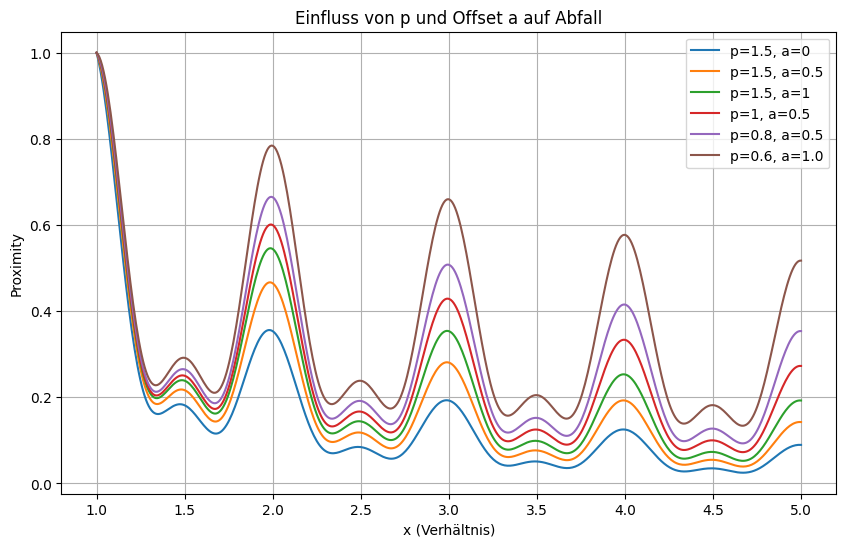

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def proximity_dual_freq(x, p=1.5, a=0.5):
    freq1 = 1
    freq2 = 2

    cos_part1 = (1 + np.cos(2 * np.pi * freq1 * x)) / 2
    cos_part2 = (1 + np.cos(2 * np.pi * freq2 * x)) / 2

    decay1 = 1 / ((x + a) ** p)
    decay2 = 1 / ((x + a) ** p)

    result = cos_part1 * decay1 + (cos_part2 * decay2) / freq2

    norm_at_1 = ((1 + np.cos(2 * np.pi * freq1 * 1)) / 2) * (1 / ((1 + a) ** p)) + (((1 + np.cos(2 * np.pi * freq2 * 1)) / 2) * (1 / ((1 + a) ** p))) / freq2
    return result / norm_at_1

x_vals = np.linspace(1, 5, 500)

plt.figure(figsize=(10,6))
for (p,a) in [(1.5,0), (1.5,0.5), (1.5,1), (1,0.5), (0.8,0.5), (0.6,1.0)]:
    y_vals = proximity_dual_freq(x_vals, p=p, a=a)
    plt.plot(x_vals, y_vals, label=f"p={p}, a={a}")

plt.xlabel("x (Verhältnis)")
plt.ylabel("Proximity")
plt.title("Einfluss von p und Offset a auf Abfall")
plt.legend()
plt.grid(True)
plt.show()


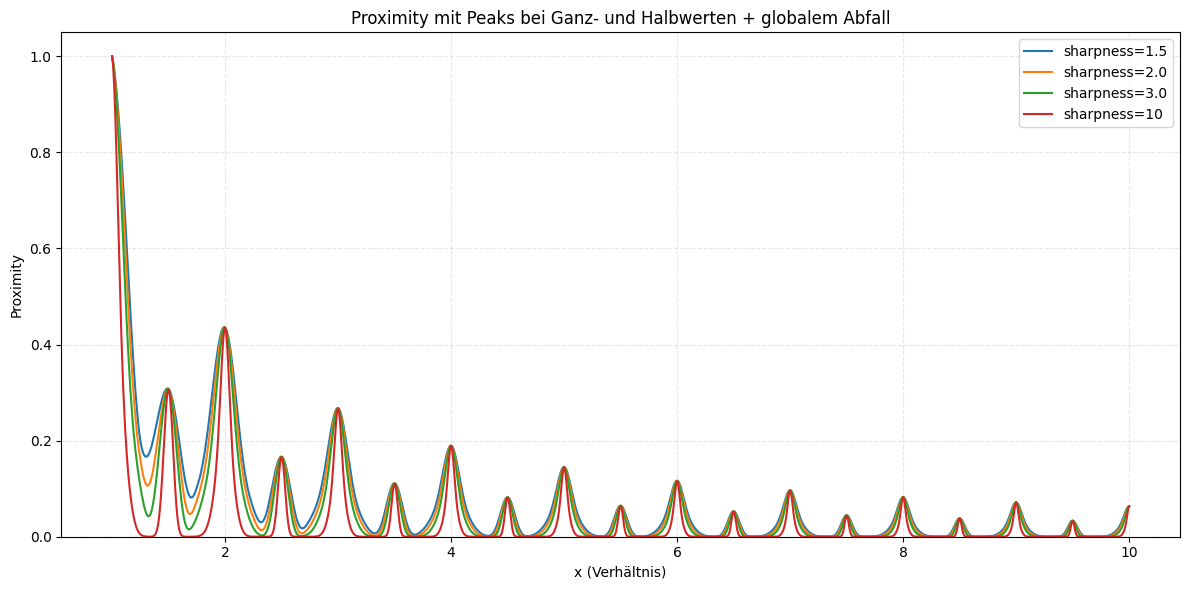

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def proximity_peaky_raw(x, sharpness_base=2.0, decay=1.0):
    x = np.array(x)
    
    a = sharpness_base * x
    
    # Beträge verwenden, damit keine komplexen Zahlen entstehen
    term1 = np.abs(np.cos(np.pi * x)) ** a
    term2 = np.abs(np.cos(np.pi * x * 2)) ** a

    combined = (term1 + term2) / 2
    proximity = combined / (x ** decay)

    return proximity

def proximity_peaky_combined(x, sharpness_base=2.0, decay=1.0):
    raw = proximity_peaky_raw(x, sharpness_base=sharpness_base, decay=decay)
    norm_val = proximity_peaky_raw(np.array([1.0]), sharpness_base=sharpness_base, decay=decay)[0]
    return raw / norm_val

# === Plot
x_vals = np.linspace(1, 10, 1000)
plt.figure(figsize=(12, 6))

for sharpness in [1.5, 2.0, 3.0]:
    y_vals = proximity_peaky_combined(x_vals, sharpness_base=sharpness, decay=1.2)
    plt.plot(x_vals, y_vals, label=f"sharpness={sharpness}")

plt.title("Proximity mit Peaks bei Ganz- und Halbwerten + globalem Abfall")
plt.xlabel("x (Verhältnis)")
plt.ylabel("Proximity")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


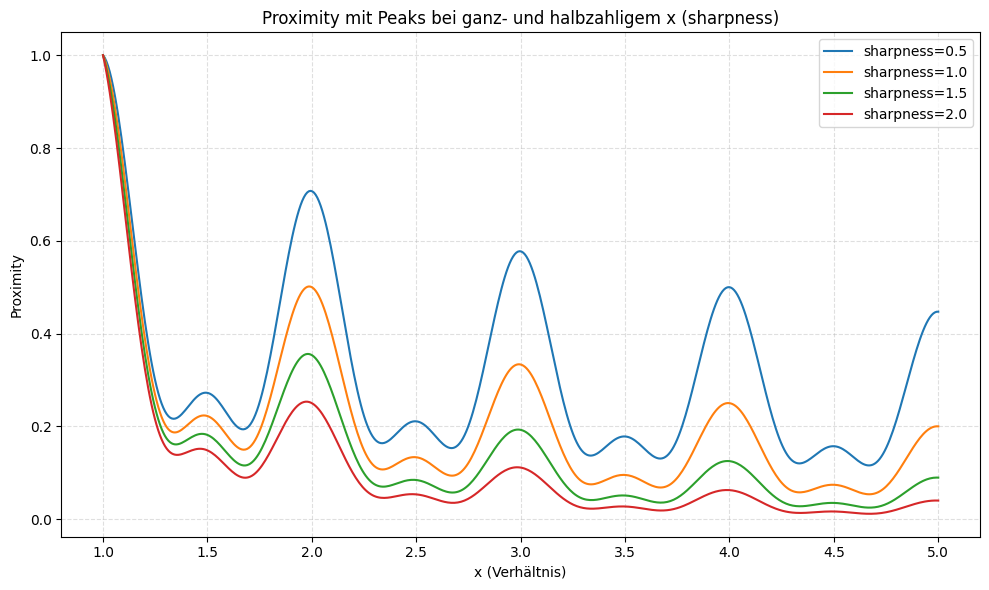

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def proximity_dual_freq_raw(x, sharpness=1.5):
    freq1 = 1
    freq2 = 2

    cos_part1 = (1 + np.cos(2 * np.pi * freq1 * x)) / 2
    cos_part2 = (1 + np.cos(2 * np.pi * freq2 * x)) / 2

    decay = 1 / (x ** sharpness)

    result = cos_part1 * decay + (cos_part2 * decay) / freq2
    return result

def proximity_dual_freq(x, sharpness=1.5):
    raw = proximity_dual_freq_raw(x, sharpness=sharpness)
    norm = proximity_dual_freq_raw(np.array([1.0]), sharpness=sharpness)[0]
    return raw / norm

# === Plot
x_vals = np.linspace(1, 5, 500)

plt.figure(figsize=(10, 6))
for sharpness in [0.5, 1.0, 1.5, 2.0]:
    y_vals = proximity_dual_freq(x_vals, sharpness=sharpness)
    plt.plot(x_vals, y_vals, label=f"sharpness={sharpness}")

plt.xlabel("x (Verhältnis)")
plt.ylabel("Proximity")
plt.title("Proximity mit Peaks bei ganz- und halbzahligem x (sharpness)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


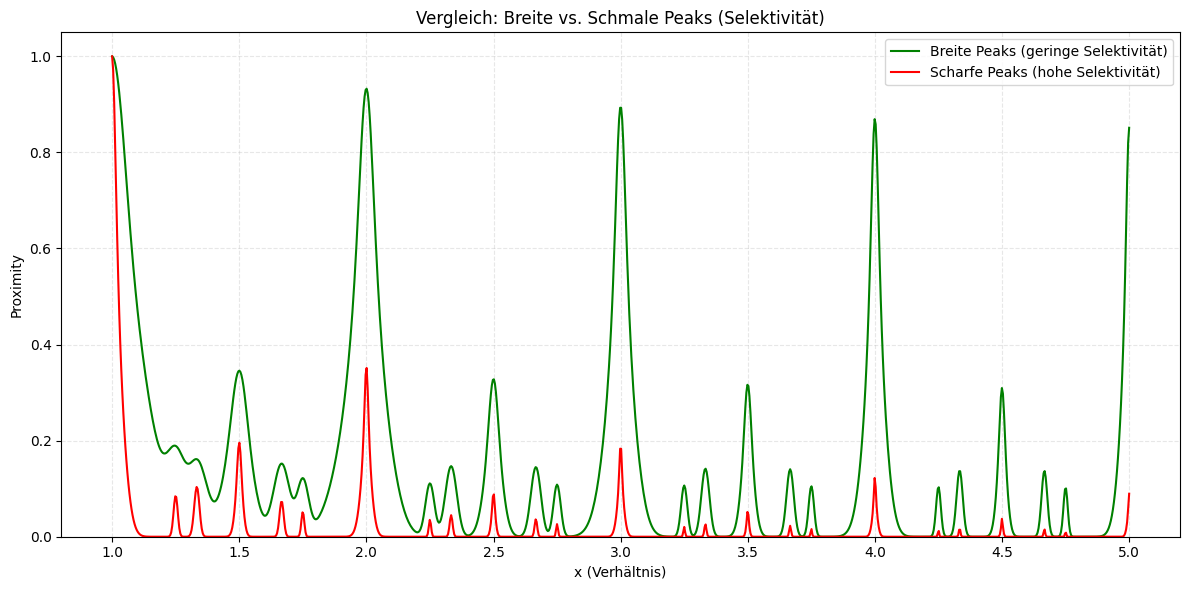

In [135]:
import numpy as np
import matplotlib.pyplot as plt

def proximity_dual_freq_raw(x, sharpness_base=2.0, sharpness_growth=1.2, decay=0):
    x = np.array(x)
    
    # Frequenzen
    freq1 = 1
    freq2 = 2
    freq3 = 3
    freq4 = 4

    # Sharpness steigt mit x
    sharpness = sharpness_base * (x ** sharpness_growth)

    # Cosine mit variabler Schärfe
    cos_part1 = ((1 + np.cos(2 * np.pi * freq1 * x)) / 2) ** sharpness
    cos_part2 = ((1 + np.cos(2 * np.pi * freq2 * x)) / 2) ** sharpness
    cos_part3 = ((1 + np.cos(2 * np.pi * freq3 * x)) / 2) ** sharpness
    cos_part4 = ((1 + np.cos(2 * np.pi * freq4 * x)) / 2) ** sharpness

    decay_factor = 1 / (x ** decay)

    result = ((cos_part1 / freq1) + (cos_part2 /freq2) + (cos_part3 / freq3) + (cos_part4 / freq4)) * decay_factor
    return result

def proximity_dual_freq(x, sharpness_base=2.0, sharpness_growth=1.2, decay=1.5):
    raw = proximity_dual_freq_raw(x, sharpness_base, sharpness_growth, decay)
    norm = proximity_dual_freq_raw(np.array([1.0]), sharpness_base, sharpness_growth, decay)[0]
    return raw / norm

# === Plot
x_vals = np.linspace(1, 5, 1000)

plt.figure(figsize=(12, 6))

# Breite Peaks: niedrige Sharpness
y_low = proximity_dual_freq(x_vals, sharpness_base=2.0, sharpness_growth=2.0, decay=0.1)
plt.plot(x_vals, y_low, label="Breite Peaks (geringe Selektivität)", color='green')

# Schmale Peaks: hohe Sharpness
y_high = proximity_dual_freq(x_vals, sharpness_base=30.0, sharpness_growth=2.0, decay=1.5)
plt.plot(x_vals, y_high, label="Scharfe Peaks (hohe Selektivität)", color='red')

plt.xlabel("x (Verhältnis)")
plt.ylabel("Proximity")
plt.title("Vergleich: Breite vs. Schmale Peaks (Selektivität)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

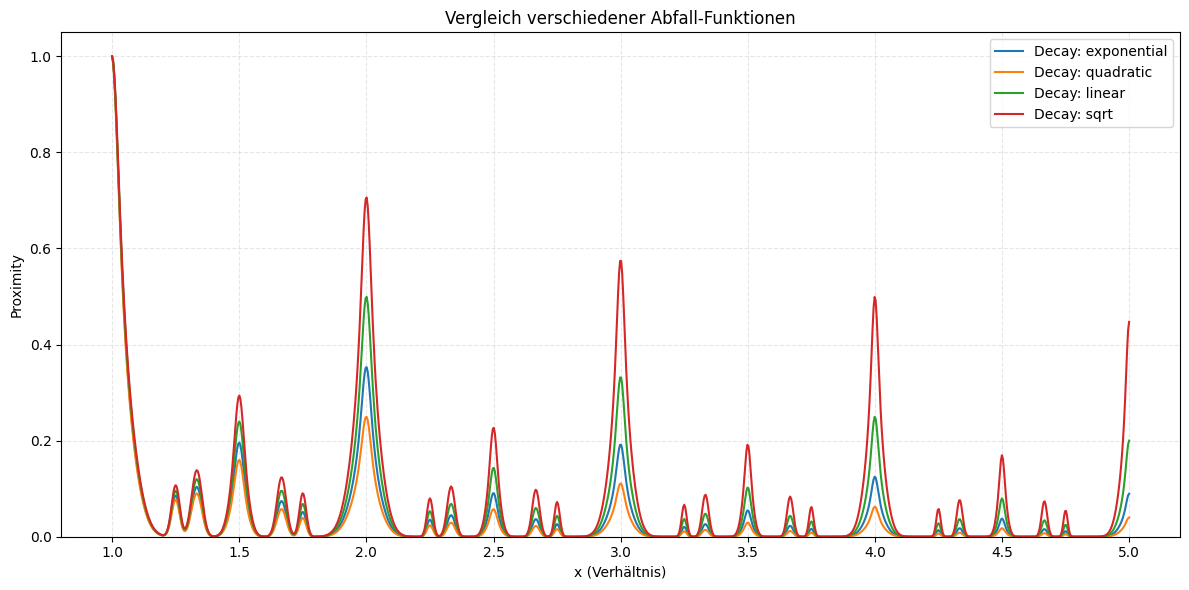

In [98]:
import numpy as np
import matplotlib.pyplot as plt

def proximity_freq_decay(x, sharpness_base=2.0, sharpness_growth=1.2, decay=1.5, decay_type='exponential'):
    x = np.array(x)
    
    freq1 = 1
    freq2 = 2
    freq3 = 3
    freq4 = 4

    sharpness = sharpness_base * (x ** sharpness_growth)

    cos_part1 = ((1 + np.cos(2 * np.pi * freq1 * x)) / 2) ** sharpness
    cos_part2 = ((1 + np.cos(2 * np.pi * freq2 * x)) / 2) ** sharpness
    cos_part3 = ((1 + np.cos(2 * np.pi * freq3 * x)) / 2) ** sharpness
    cos_part4 = ((1 + np.cos(2 * np.pi * freq4 * x)) / 2) ** sharpness

    # Unterschiedliche Abfallformen
    if decay_type == 'exponential':
        decay_factor = 1 / (x ** decay)
    elif decay_type == 'quadratic':
        decay_factor = 1 / (x ** 2)
    elif decay_type == 'linear':
        decay_factor = 1 / x
    elif decay_type == 'sqrt':
        decay_factor = 1 / np.sqrt(x)
    else:
        raise ValueError("Unbekannter decay_type")

    result = (cos_part1 + cos_part2 / freq2 + cos_part3 / freq3 + cos_part4 / freq4) * decay_factor
    return result

def proximity_freq_norm(x, sharpness_base=2.0, sharpness_growth=1.2, decay=1.5, decay_type='exponential'):
    raw = proximity_freq_decay(x, sharpness_base, sharpness_growth, decay, decay_type)
    norm = proximity_freq_decay(np.array([1.0]), sharpness_base, sharpness_growth, decay, decay_type)[0]
    return raw / norm

x_vals = np.linspace(1, 5, 1000)

plt.figure(figsize=(12, 6))
params = dict(sharpness_base=10.0, sharpness_growth=1.0, decay=1.5)

for decay_t in ['exponential', 'quadratic', 'linear', 'sqrt']:
    y_vals = proximity_freq_norm(x_vals, decay_type=decay_t, **params)
    plt.plot(x_vals, y_vals, label=f"Decay: {decay_t}")

plt.title("Vergleich verschiedener Abfall-Funktionen")
plt.xlabel("x (Verhältnis)")
plt.ylabel("Proximity")
plt.grid(True, linestyle="--", alpha=0.3)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


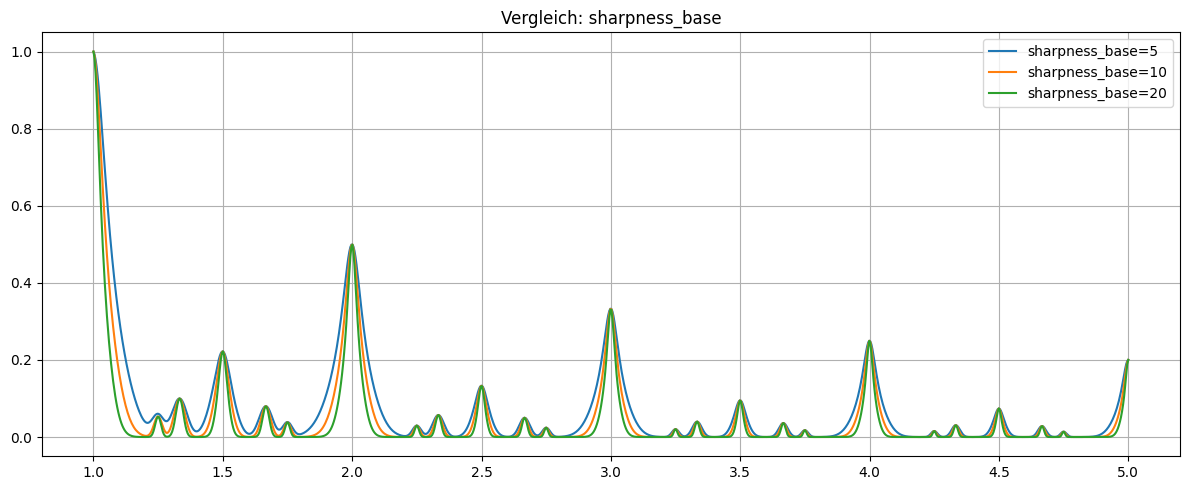

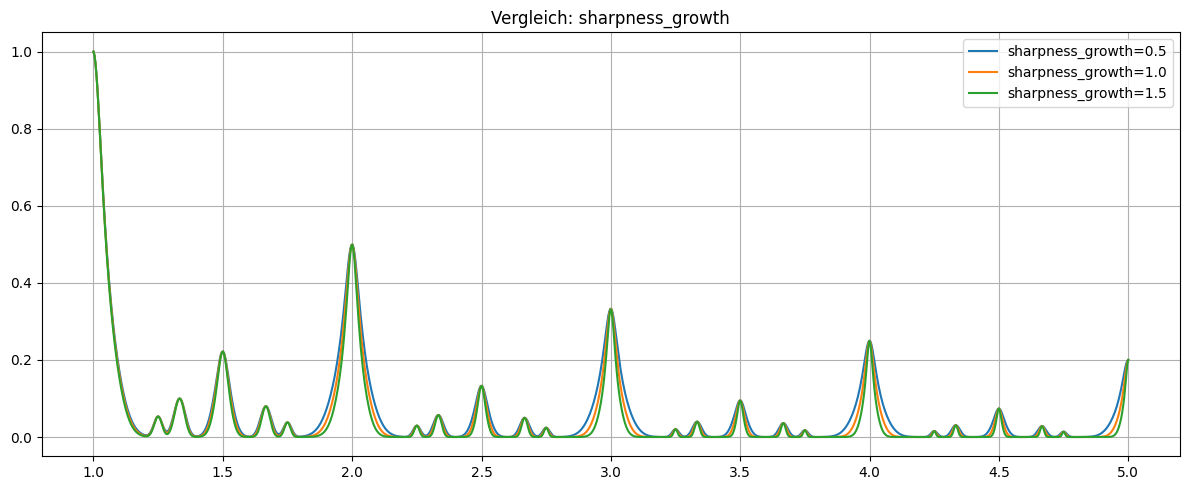

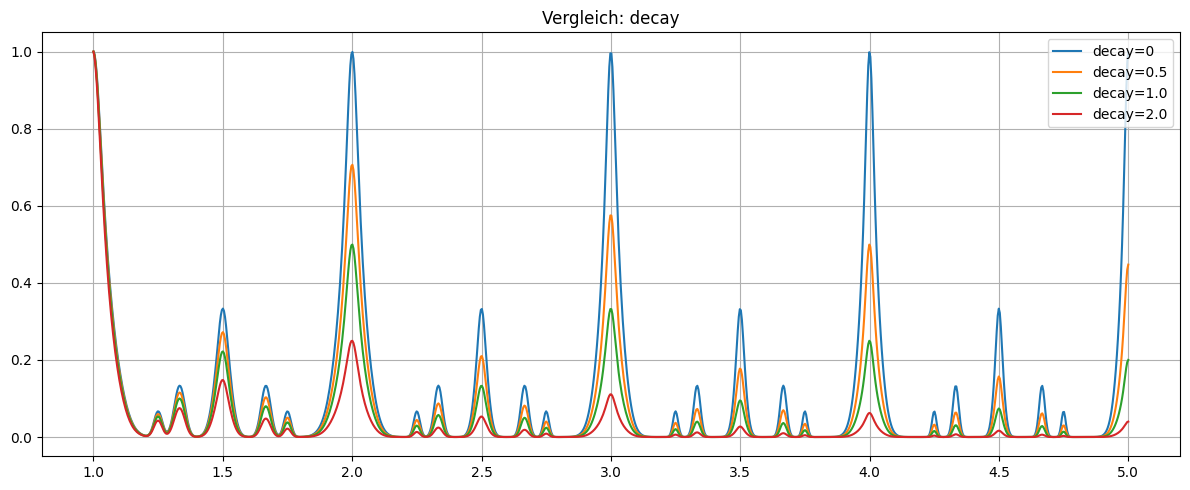

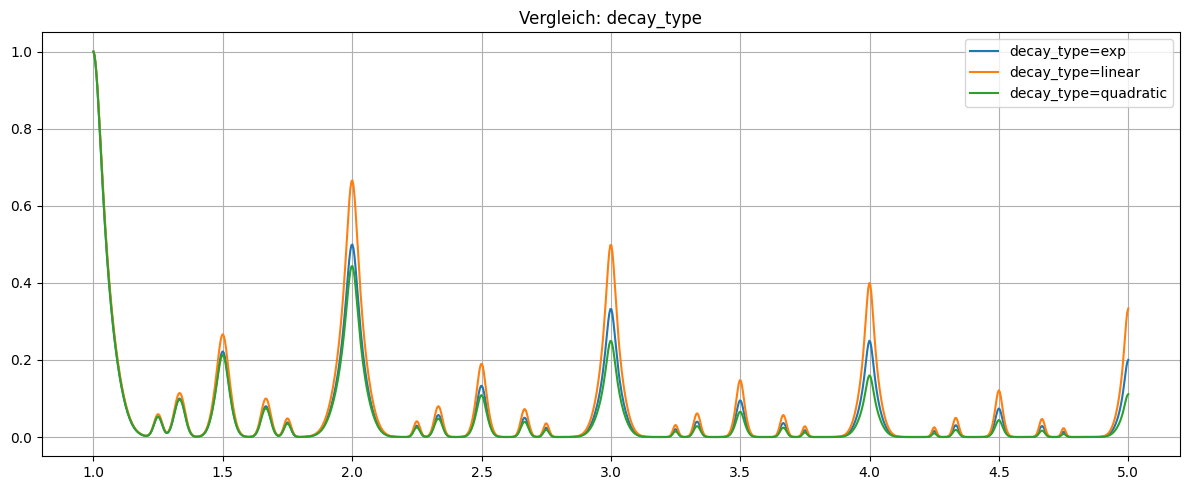

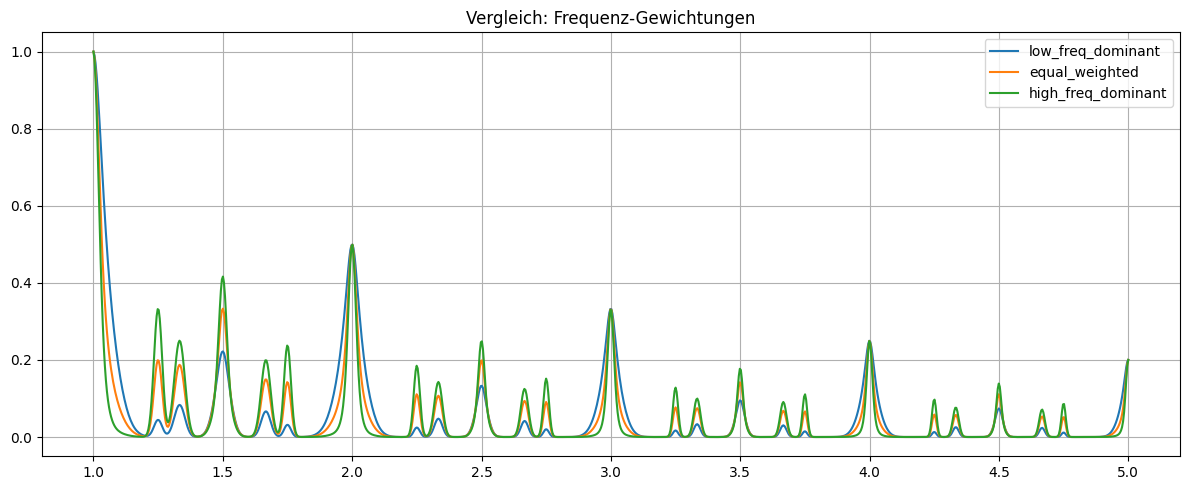

In [108]:
def proximity_freq_weighted(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=1.0,
    decay_type="exp",
    freqs=[1, 2, 3, 4],
    weights=[1.0, 0.5, 0.25, 0.125],
    norm_x=1.0,
    do_normalize=True  # 👈 verhindert Rekursion!
):
    x = np.array(x)
    sharpness = sharpness_base * (x ** sharpness_growth)

    total = 0
    for f, w in zip(freqs, weights):
        cos_part = ((1 + np.cos(2 * np.pi * f * x)) / 2) ** sharpness
        total += w * cos_part

    if decay_type == "exp":
        decay_factor = 1 / (x ** decay)
    elif decay_type == "linear":
        decay_factor = 1 / (x + decay)
    elif decay_type == "quadratic":
        decay_factor = 1 / ((x + decay) ** 2)
    else:
        raise ValueError("Unknown decay_type")

    result = total * decay_factor

    if do_normalize:
        norm = proximity_freq_weighted(
            np.array([norm_x]),
            sharpness_base=sharpness_base,
            sharpness_growth=sharpness_growth,
            decay=decay,
            decay_type=decay_type,
            freqs=freqs,
            weights=weights,
            norm_x=norm_x,
            do_normalize=False  # 👈 wichtig!
        )[0]
        return result / norm
    else:
        return result

x_vals = np.linspace(1, 5, 1000)
base_settings = {
    "sharpness_base": 10.0,
    "sharpness_growth": 1.0,
    "decay": 1.0,
    "decay_type": "exp",
    "freqs": [1, 2, 3, 4],
    "weights": [1.0, 0.5, 0.25, 0.125],
}

# === 1. sharpness_base
sharpness_bases = [5, 10, 20]
plt.figure(figsize=(12, 5))
for val in sharpness_bases:
    settings = base_settings.copy()
    settings["sharpness_base"] = val
    y = proximity_freq_weighted(x_vals, **settings)
    plt.plot(x_vals, y, label=f"sharpness_base={val}")
plt.title("Vergleich: sharpness_base")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# === 2. sharpness_growth
sharpness_growths = [0.5, 1.0, 1.5]
plt.figure(figsize=(12, 5))
for val in sharpness_growths:
    settings = base_settings.copy()
    settings["sharpness_growth"] = val
    y = proximity_freq_weighted(x_vals, **settings)
    plt.plot(x_vals, y, label=f"sharpness_growth={val}")
plt.title("Vergleich: sharpness_growth")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# === 3. decay
decay_values = [0, 0.5, 1.0, 2.0]
plt.figure(figsize=(12, 5))
for val in decay_values:
    settings = base_settings.copy()
    settings["decay"] = val
    y = proximity_freq_weighted(x_vals, **settings)
    plt.plot(x_vals, y, label=f"decay={val}")
plt.title("Vergleich: decay")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# === 4. decay_type
decay_types = ["exp", "linear", "quadratic"]
plt.figure(figsize=(12, 5))
for val in decay_types:
    settings = base_settings.copy()
    settings["decay_type"] = val
    y = proximity_freq_weighted(x_vals, **settings)
    plt.plot(x_vals, y, label=f"decay_type={val}")
plt.title("Vergleich: decay_type")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# === 5. weight_sets
weight_sets = {
    "low_freq_dominant": [1.0, 0.5, 0.2, 0.1],
    "equal_weighted":    [1.0, 1.0, 1.0, 1.0],
    "high_freq_dominant": [0.1, 0.5, 0.8, 1.0],
}
plt.figure(figsize=(12, 5))
for label, weights in weight_sets.items():
    settings = base_settings.copy()
    settings["weights"] = weights
    y = proximity_freq_weighted(x_vals, **settings)
    plt.plot(x_vals, y, label=label)
plt.title("Vergleich: Frequenz-Gewichtungen")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


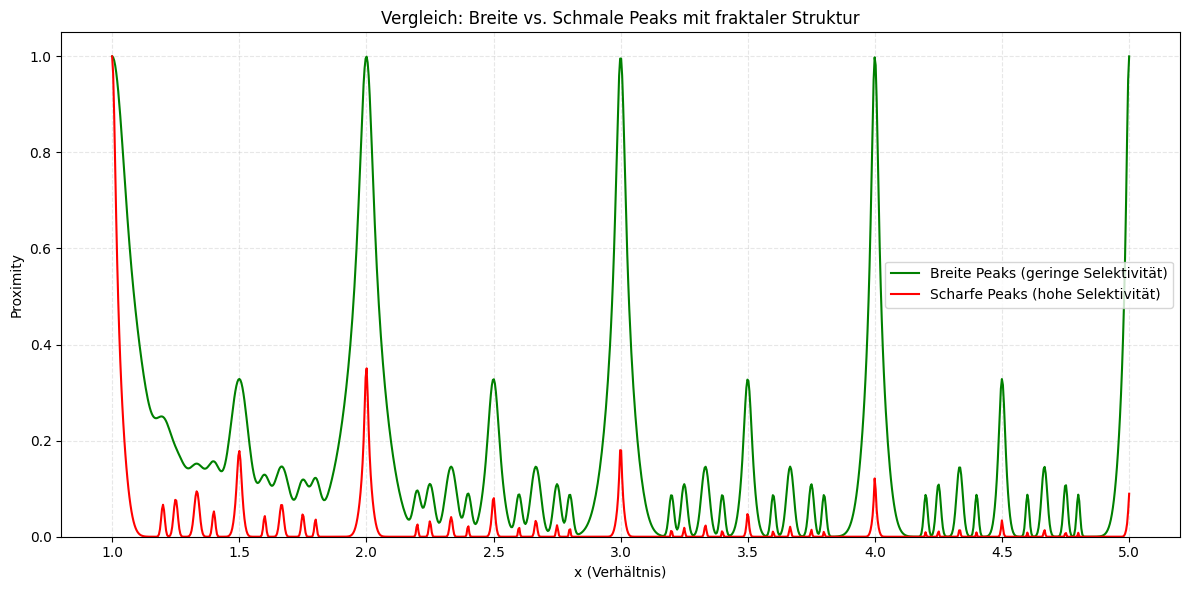

In [167]:
import numpy as np
import matplotlib.pyplot as plt

def proximity_fractal_peaks_raw(x, sharpness_base=2.0, sharpness_growth=1.2, decay=1.5, max_freq=4):
    x = np.array(x)
    sharpness = sharpness_base * (x ** sharpness_growth)

    result = np.zeros_like(x, dtype=float)

    for freq in range(1, max_freq + 1):
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness
        result += cos_term / freq  # Gewichtung: höhere Frequenzen haben geringeren Einfluss

    decay_factor = 1 / (x ** decay)
    return result * decay_factor

def proximity_fractal_peaks(x, sharpness_base=2.0, sharpness_growth=1.2, decay=1.5, max_freq=4):
    raw = proximity_fractal_peaks_raw(x, sharpness_base, sharpness_growth, decay, max_freq)
    norm = proximity_fractal_peaks_raw(np.array([1.0]), sharpness_base, sharpness_growth, decay, max_freq)[0]
    return raw / norm

# === Plot
x_vals = np.linspace(1, 5, 1000)
plt.figure(figsize=(12, 6))

# Breite Peaks
y_low = proximity_fractal_peaks(x_vals, sharpness_base=2.0, sharpness_growth=2.0, decay=0, max_freq=5)
plt.plot(x_vals, y_low, label="Breite Peaks (geringe Selektivität)", color='green')

# Schmale Peaks
y_high = proximity_fractal_peaks(x_vals, sharpness_base=30.0, sharpness_growth=2.0, decay=1.5, max_freq=5)
plt.plot(x_vals, y_high, label="Scharfe Peaks (hohe Selektivität)", color='red')

plt.xlabel("x (Verhältnis)")
plt.ylabel("Proximity")
plt.title("Vergleich: Breite vs. Schmale Peaks mit fraktaler Struktur")
plt.grid(True, linestyle="--", alpha=0.3)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

def proximity_fractal_peaks_raw(x, sharpness_base=2.0, sharpness_growth=1.2, decay=1.5, max_freq=4, weight_exponent=1.0):
    x = np.array(x)
    sharpness = sharpness_base * (x ** sharpness_growth)
    result = np.zeros_like(x, dtype=float)

    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness
        result += weight * cos_term

    decay_factor = 1 / (x ** decay)
    return result * decay_factor

def proximity_fractal_peaks(x, **kwargs):
    raw = proximity_fractal_peaks_raw(x, **kwargs)
    norm = proximity_fractal_peaks_raw(np.array([1.0]), **kwargs)[0]
    return raw / norm

def interactive_plot(
    sharpness_base=10.0, 
    sharpness_growth=2.0, 
    decay=1.0, 
    max_freq=4, 
    weight_exponent=1.0
):
    x_vals = np.linspace(1, 5, 1000)
    y_vals = proximity_fractal_peaks(
        x_vals,
        sharpness_base=sharpness_base,
        sharpness_growth=sharpness_growth,
        decay=decay,
        max_freq=max_freq,
        weight_exponent=weight_exponent
    )

    plt.figure(figsize=(10, 5))
    plt.plot(x_vals, y_vals, color='royalblue')
    plt.ylim(0, 1.05)
    plt.xlabel("x (Verhältnis)")
    plt.ylabel("Proximity")
    plt.title("Interaktive Fraktal-Peaks")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    interactive_plot,
    sharpness_base=FloatSlider(min=1.0, max=50.0, step=1.0, value=10.0, description='Sharpness Base'),
    sharpness_growth=FloatSlider(min=0.0, max=3.0, step=0.1, value=2.0, description='Sharpness Growth'),
    decay=FloatSlider(min=0.0, max=3.0, step=0.1, value=1.0, description='Decay'),
    max_freq=IntSlider(min=1, max=12, step=1, value=4, description='Max Freq'),
    weight_exponent=FloatSlider(min=0.0, max=3.0, step=0.1, value=1.0, description='Weight Exp')
)


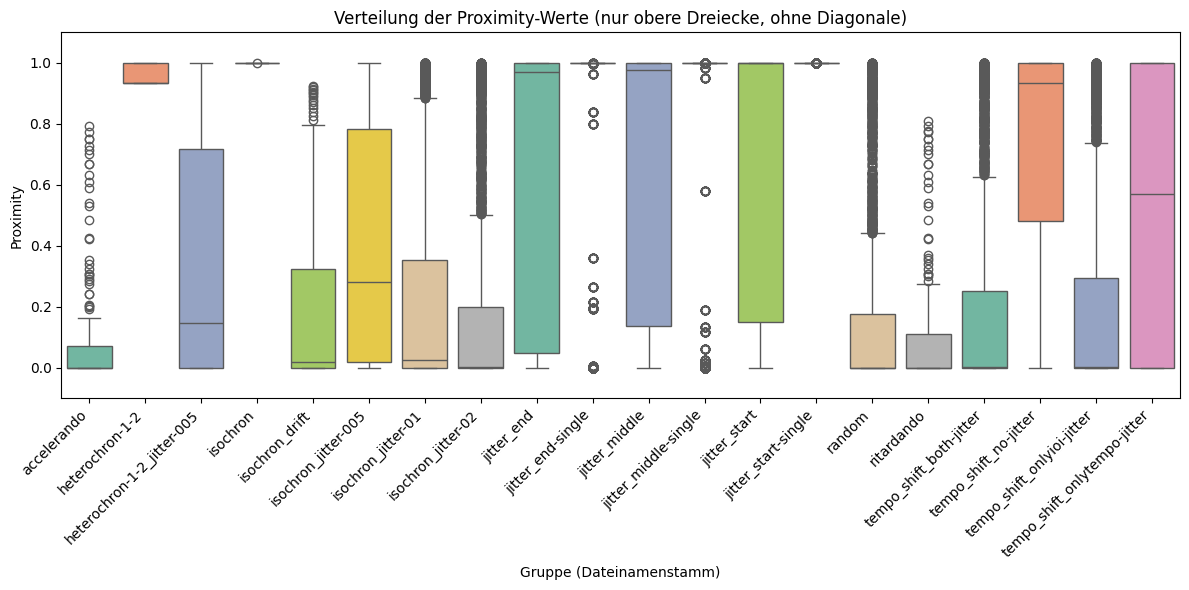

In [ ]:
# Analysis of Proximity Values from Synthetic 20-Beats Sequences
# Boxplot of Proximity Values for Each Group

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from pathlib import Path

# === Pfad zur 20-Beats Sequenz-Ordner ===
data_dir = Path("../data/theoretical_sequences/synthetic_sequences_20beats")
all_csv_files = list(data_dir.glob("*.csv"))

# === Container für Ergebnisse ===
all_results = []

# === Funktion zur Gruppierung aus Dateinamen extrahieren ===
def extract_group_name(filename):
    # Entferne Index vor ".csv", z.B. "_04.csv"
    return re.sub(r"_\d+(?=\.csv)", "", filename).replace(".csv", "")

# === Analyse-Funktion wiederverwenden ===
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []
    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value
        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)
    result = np.maximum.reduce(all_freq_values)
    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# === Haupt-Loop über alle Dateien ===
for file_path in all_csv_files:
    try:
        df = pd.read_csv(file_path)
        iois = df["IOI"].dropna().values
        if len(iois) < 2:
            continue  # überspringen, wenn zu wenig Daten

        ratios = np.array([[max(x, y) / min(x, y) for x in iois] for y in iois])
        proximity = proximity_max_freq(
            ratios,
            sharpness_base=10.0,
            sharpness_growth=2.0,
            decay=0.1,
            max_freq=4,
            weight_exponent=1.0,
            freq_sharpness_exp=1.0,
            norm_x=1.0,
            output_max=1.0
        )

        # Nur oberes Dreieck ohne Diagonale nehmen
        upper_triangle_values = proximity[np.triu_indices_from(proximity, k=1)]

        # Gruppe extrahieren
        group_name = extract_group_name(file_path.name)

        # Ergebnis speichern
        for val in upper_triangle_values:
            all_results.append({
                "group": group_name,
                "proximity": val
            })

    except Exception as e:
        print(f"Fehler bei Datei {file_path.name}: {e}")

# === In DataFrame umwandeln ===
results_df = pd.DataFrame(all_results)
results_df["group"] = pd.Categorical(results_df["group"], categories=sorted(results_df["group"].unique()), ordered=True)

# === Plot: Boxplot pro Gruppe ===
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, x="group", y="proximity", hue="group", palette="Set2", legend=False)
plt.xticks(rotation=45, ha="right")
plt.ylim(-0.1, 1.1)
plt.title("Verteilung der Proximity-Werte (nur obere Dreiecke, ohne Diagonale)")
plt.xlabel("Gruppe (Dateinamenstamm)")
plt.ylabel("Proximity")
plt.tight_layout()
plt.show()
